In [139]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [140]:
df = pd.read_csv(
    "APL_Logistics.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (180519, 40)


In [141]:

df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [142]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
180514,TRANSFER,6,4,-107.96,161.87,Late delivery,1,76,Women's Clothing,Caguas,...,1,215.82,161.87,-107.96,Southeast Asia,Java Occidental,PROCESSING,Summer dresses,215.82,Standard Class
180515,DEBIT,2,4,-126.56,172.66,Advance shipping,0,76,Women's Clothing,Plainfield,...,1,215.82,172.66,-126.56,Southeast Asia,Java Occidental,COMPLETE,Summer dresses,215.82,Standard Class
180516,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.75,Standard Class
180517,PAYMENT,4,4,1.53,10.91,Shipping on time,0,74,Toys,Berwyn,...,1,11.54,10.91,1.53,Southeast Asia,Java Occidental,PENDING_PAYMENT,Toys,11.54,Standard Class
180518,CASH,1,0,9.79,34.98,Late delivery,1,75,Video Games,Miami,...,1,39.75,34.98,9.79,Oceania,Queensland,CLOSED,Fighting video games,39.75,Same Day


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [144]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']


In [145]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.98,7.0,31.52,64.8,911.8
Sales per customer,180519.0,NaN,NaN,NaN,183.107607,120.043668,7.49,104.38,163.99,247.4,1939.99
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

missing_df.head(20)

,Column,Missing Values,Missing %
13,Customer Lname,8,0.004432
17,Customer Zipcode,3,0.001662
0,Type,0,0.000000
1,Days for shipping (real),0,0.000000
4,Sales per customer,0,0.000000
5,Delivery Status,0,0.000000
2,Days for shipment (scheduled),0,0.000000
3,Benefit per order,0,0.000000
7,Category Id,0,0.000000
6,Late_delivery_risk,0,0.000000


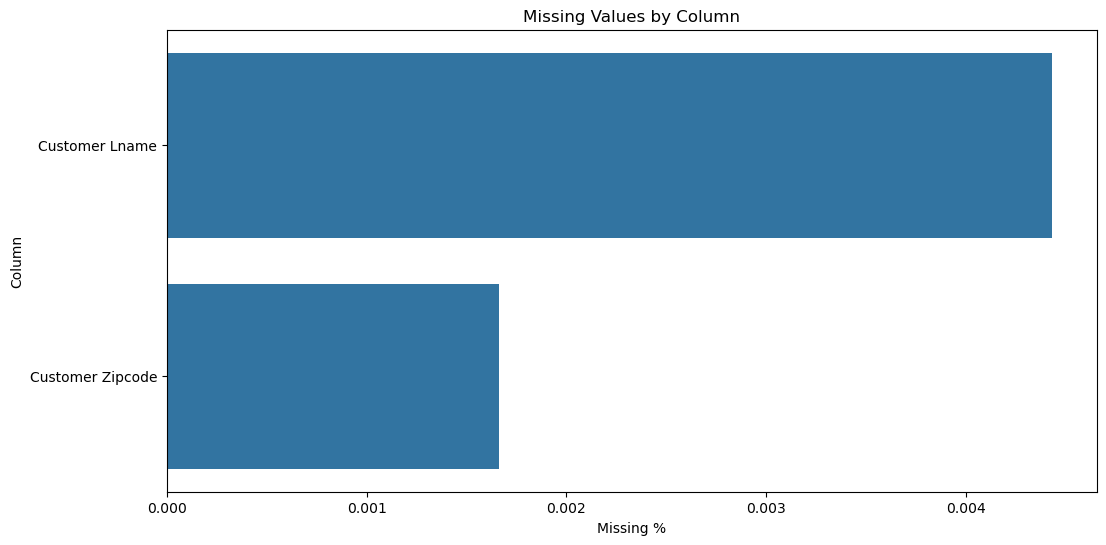

In [147]:
plt.figure(figsize=(12, 6))

missing_plot = missing_df[
    missing_df["Missing Values"] > 0
]

sns.barplot(
    data=missing_plot,
    x="Missing %",
    y="Column"
)

plt.title("Missing Values by Column")
plt.show()

In [148]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [149]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (180519, 40)


In [150]:
print(df["Late_delivery_risk"].value_counts())

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [151]:
target_percentage = (
    df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .mul(100)
)

print(target_percentage)

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


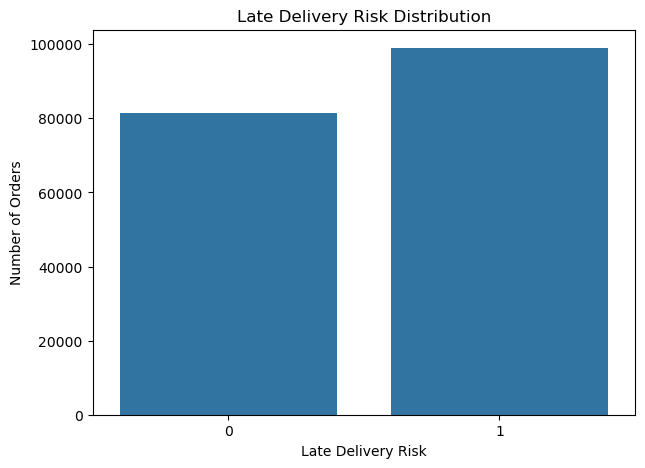

In [152]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

In [153]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


In [154]:
for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])


Type
Unique values: 4
['DEBIT' 'PAYMENT' 'TRANSFER' 'CASH']

Delivery Status
Unique values: 4
['Late delivery' 'Shipping on time' 'Advance shipping' 'Shipping canceled']

Category Name
Unique values: 50
['Cardio Equipment' 'Shop By Sport' 'Water Sports' "Women's Apparel"
 'Camping & Hiking' 'Indoor/Outdoor Games' 'Fishing' 'Cleats'
 'Electronics' "Men's Footwear" 'Accessories' 'Fitness Accessories'
 'Trade-In' 'Baseball & Softball' 'Golf Gloves' "Men's Golf Clubs"
 'Golf Balls' 'Hockey' 'Golf Shoes' 'Boxing & MMA']

Customer City
Unique values: 563
['Brownsville' 'Littleton' 'Caguas' 'San Marcos' 'Passaic' 'Lawrence'
 'Stafford' 'San Antonio' 'Pico Rivera' 'Fontana' 'Taylor' 'Martinez'
 'West New York' 'North Bergen' 'San Juan' 'Peoria' 'Glenview' 'Longview'
 'Fort Worth' 'Albuquerque']

Customer Country
Unique values: 2
['EE. UU.' 'Puerto Rico']

Customer Fname
Unique values: 782
['Richard' 'Mary' 'Ann' 'Robert' 'Melissa' 'Megan' 'Christopher'
 'Katherine' 'Jane' 'Tiffany' 'Stephanie

In [155]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print(numerical_columns.tolist())

['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


In [156]:
leakage_columns = [
    "Days for shipping (real)",
    "Delivery Status"
]

for col in leakage_columns:
    if col in df.columns:
        print("Removing leakage column:", col)

df_model = df.drop(
    columns=leakage_columns,
    errors="ignore"
)

print("New shape:", df_model.shape)

Removing leakage column: Days for shipping (real)
Removing leakage column: Delivery Status
New shape: (180519, 38)


In [157]:
drop_columns = [
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Customer Id",
    "Order Customer Id",
    "Category Id",
    "Department Id",
    "Order Id",
    "Product Card Id"
]

df_model = df_model.drop(
    columns=drop_columns,
    errors="ignore"
)

print("Shape:", df_model.shape)

Shape: (180519, 30)


In [158]:
df_model["Shipping_Pressure"] = (
    df_model["Order Item Quantity"] /
    (df_model["Days for shipment (scheduled)"] + 1)
)

In [159]:
df_model["Discount_Amount_Ratio"] = (
    df_model["Order Item Discount"] /
    (df_model["Sales"] + 1)
)

In [160]:
quantity_median = df_model["Order Item Quantity"].median()

df_model["High_Quantity_Flag"] = (
    df_model["Order Item Quantity"] > quantity_median
).astype(int)

In [161]:
if "Shipping Mode" in df_model.columns:

    df_model["Express_Shipping_Flag"] = (
        df_model["Shipping Mode"]
        .astype(str)
        .str.lower()
        .str.contains("express")
        .astype(int)
    )

In [162]:
discount_median = df_model["Order Item Discount Rate"].median()

df_model["High_Discount_Flag"] = (
    df_model["Order Item Discount Rate"] >
    discount_median
).astype(int)

In [163]:
df_model[
    [
        "Shipping_Pressure",
        "Discount_Amount_Ratio",
        "High_Quantity_Flag",
        "High_Discount_Flag"
    ]
].head()

,Shipping_Pressure,Discount_Amount_Ratio,High_Quantity_Flag,High_Discount_Flag
0,1.0,0.054896,1,0
1,1.0,0.159194,1,1
2,0.2,0.089557,0,0
3,0.2,0.119409,0,1
4,0.2,0.196078,0,1


In [164]:
shipping_risk = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

print(shipping_risk)

Late_delivery_risk          0          1
Shipping Mode                           
First Class          4.677501  95.322499
Same Day            54.256958  45.743042
Second Class        23.367219  76.632781
Standard Class      61.928317  38.071683


In [165]:
shipping_risk = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

print(shipping_risk)

Late_delivery_risk          0          1
Shipping Mode                           
First Class          4.677501  95.322499
Same Day            54.256958  45.743042
Second Class        23.367219  76.632781
Standard Class      61.928317  38.071683


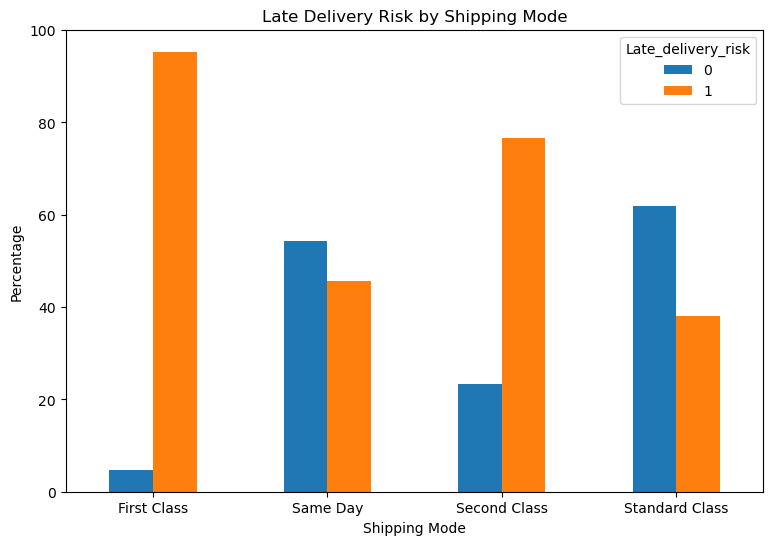

In [166]:
shipping_risk.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.ylabel("Percentage")
plt.xlabel("Shipping Mode")
plt.xticks(rotation=0)

plt.show()